In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import ( 
accuracy_score, precision_score, recall_score, f1_score, 
confusion_matrix, classification_report 
) 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.utils import to_categorical

In [10]:
df = pd.read_csv('your_file.csv') 
print(df)

   Experience  Education  Age  Salary
0           1         12   22   25000
1           2         12   24   30000
2           3         14   26   38000
3           4         14   28   45000
4           5         15   30   52000
5           6         16   32   60000
6           7         16   34   68000
7           8         18   36   75000
8           9         18   38   82000
9          10         18   40   90000


In [11]:
salary = df['Salary'] 
conditions = [ 
salary < 45000, 
(salary >= 45000) & (salary < 75000), 
salary >= 75000 
] 
choices = [0, 1, 2] 
df['SalaryClass'] = np.select(conditions, choices)

In [12]:
X = df[['Experience', 'Education', 'Age']] 
y = df['SalaryClass']

In [14]:
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.3, random_state=42, stratify=y 
)

In [15]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [16]:
y_train_cat = to_categorical(y_train, num_classes=3) 
y_test_cat = to_categorical(y_test, num_classes=3)

In [17]:
ann = Sequential([ 
Dense(16, activation='relu', input_shape=(3,)), 
Dense(8, activation='relu'), 
Dense(3, activation='softmax') 
])

e:\anaconda3\envs\ml_lab\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
ann.compile( 
optimizer='adam', 
loss='categorical_crossentropy', 
metrics=['accuracy'] 
) 

In [19]:
history = ann.fit( 
X_train_scaled, y_train_cat, 
validation_split=0.2, 
epochs=100, 
batch_size=8, 
verbose=1 
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 1.2484 - val_accuracy: 0.5000 - val_loss: 1.2144
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.0000e+00 - loss: 1.2361 - val_accuracy: 0.5000 - val_loss: 1.1922
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.0000e+00 - loss: 1.2239 - val_accuracy: 0.5000 - val_loss: 1.1704
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.0000e+00 - loss: 1.2118 - val_accuracy: 0.5000 - val_loss: 1.1490
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.0000e+00 - loss: 1.1999 - val_accuracy: 0.5000 - val_loss: 1.1280
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.0000e+00 - loss: 1.1879 - val_accuracy: 0.5000 - val_loss: 1.1076
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.2000 - loss: 1.1759 - val_accuracy: 0.5000 - val_loss: 1.0891
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.2000 - loss: 1.1640 - val

In [20]:
y_pred_prob = ann.predict(X_test_scaled) 
y_pred = np.argmax(y_pred_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


In [21]:
acc = accuracy_score(y_test, y_pred) 
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0) 
rec_macro  = recall_score(y_test, y_pred, average='macro', zero_division=0) 
f1_macro   = f1_score(y_test, y_pred, average='macro', zero_division=0) 
prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0) 
rec_weighted  = recall_score(y_test, y_pred, average='weighted', zero_division=0) 
f1_weighted   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

In [22]:
print("Accuracy:", acc) 
print("\nMacro Average:") 
print("Precision (Macro):", prec_macro) 
print("Recall (Macro):   ", rec_macro) 
print("F1-score (Macro): ", f1_macro) 
print("\nWeighted Average:") 
print("Precision (Weighted):", prec_weighted) 
print("Recall (Weighted):   ", rec_weighted) 
print("F1-score (Weighted): ", f1_weighted) 
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n", 
classification_report(y_test, y_pred, 
target_names=['Low', 'Medium', 'High'], 
zero_division=0))

Accuracy: 0.6666666666666666

Macro Average:
Precision (Macro): 0.5
Recall (Macro):    0.6666666666666666
F1-score (Macro):  0.5555555555555555

Weighted Average:
Precision (Weighted): 0.5
Recall (Weighted):    0.6666666666666666
F1-score (Weighted):  0.5555555555555555

Confusion Matrix:
 [[1 0 0]
 [1 0 0]
 [0 0 1]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.50      1.00      0.67         1
      Medium       0.00      0.00      0.00         1
        High       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



In [23]:
input_data = [[6, 16, 30]] 
input_scaled = scaler.transform(input_data) 
predicted_class = np.argmax(ann.predict(input_scaled), axis=1)[0] 
labels = ['Low', 'Medium', 'High'] 
print("\nPredicted Class:", labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

e:\anaconda3\envs\ml_lab\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

Predicted Class: Medium


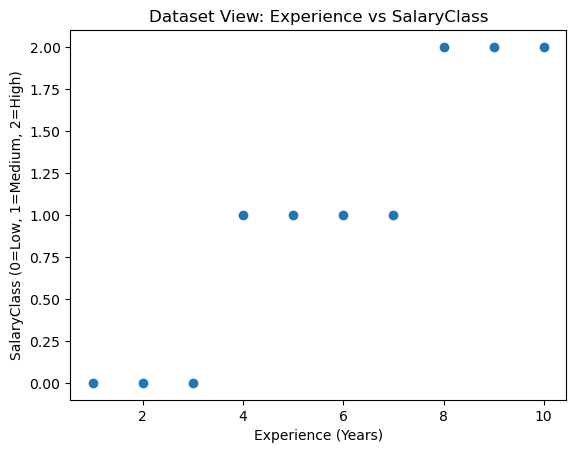

In [24]:
plt.scatter(df['Experience'], df['SalaryClass']) 
plt.xlabel('Experience (Years)') 
plt.ylabel('SalaryClass (0=Low, 1=Medium, 2=High)') 
plt.title('Dataset View: Experience vs SalaryClass') 
plt.show() 

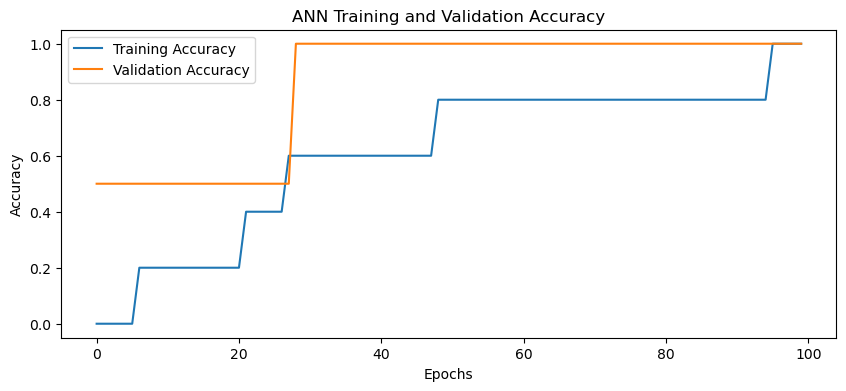

In [25]:
plt.figure(figsize=(10, 4)) 
plt.plot(history.history['accuracy'], label='Training Accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') 
plt.xlabel("Epochs") 
plt.ylabel("Accuracy") 
plt.title("ANN Training and Validation Accuracy") 
plt.legend() 
plt.show()

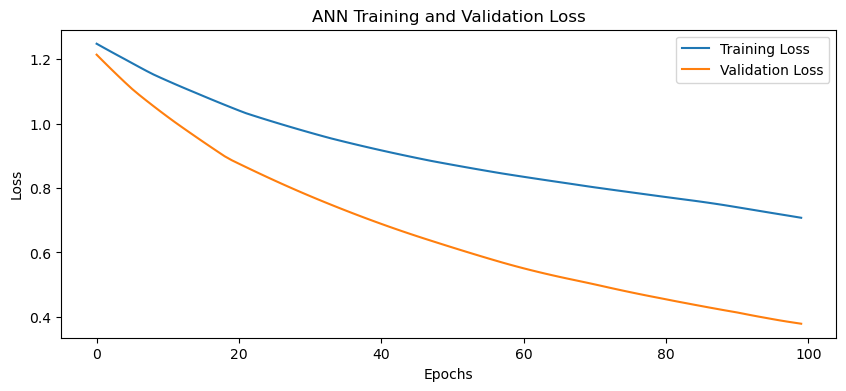

In [26]:
plt.figure(figsize=(10, 4)) 
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.xlabel("Epochs") 
plt.ylabel("Loss") 
plt.title("ANN Training and Validation Loss") 
plt.legend() 
plt.show()